## 02_entrenamiento.ipynb

In [21]:
from pathlib import Path
from typing import Any, Tuple, Callable

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import colormaps
import matplotlib.pyplot as plt

from numpy import dtype, float64
from scipy.spatial.distance import cdist

from minisom import MiniSom
from sklearn.cluster import KMeans
from mealpy import FloatVar, ABC, Problem
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

from keras.models import Model
from keras.layers import Input, Dense

### Definiendo constantes del notebook

In [23]:
GRAPH_BASE_PATH = Path("./graphs/training/")


### Cargando datos tipo PCA (10 dimensiones)

In [24]:
# Leyendo datos de archivo "pca_data.csv"

data = pd.read_csv("../data/processed/pca_data.csv")
data.head(20) 

,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,04/06/2001,P1,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349
1,04/06/2001,P2,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170
2,04/06/2001,P3,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689
3,04/06/2001,P4,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264
4,04/07/2001,P1,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335
5,04/07/2001,P2,-2.132548,0.532214,-0.262256,0.078161,-0.227430,-0.337815,-0.472315,-0.422092,-0.392760,-0.015021
6,04/07/2001,P3,-2.117197,0.478984,-0.206697,0.078746,-0.231596,-0.325558,-0.468654,-0.420190,-0.383090,0.023730
7,04/07/2001,P4,-2.098488,0.522425,-0.254046,0.106607,-0.230658,-0.215664,-0.346504,-0.424520,-0.464356,0.012026
8,20/03/2002,P1,-2.358286,0.339262,-0.034405,0.217801,-0.236129,-0.071839,-0.443520,-0.288653,-0.345643,0.393474
9,20/03/2002,P2,-2.237500,0.425845,-0.233494,0.152536,-0.242958,-0.155881,-0.544733,-0.161736,-0.370111,0.375676


## Entrenamiento para clasificación de perfiles químicos

Para realizar un entrenamiento no supervisado con una base de datos de parámetros químicos, la mejor opción es utilizar un Mapa Auto-Organizado (SOM) o un Autoencoder. Sin embargo, dado que ya se tiene los componentes principales (PCA), la técnica más robusta y estándar para encontrar grupos (clusters) es el K-Means Clustering o derivados. En este estudio se empleara una combinación con ABC (Artificial Bee Colony) que es un algoritmo de busqueda de minimos o maximos locales.

### Preparación de los datos (Inputs del PCA)

Usaremos los componentes que explican la mayor parte de la varianza (según tu tabla, los primeros 5 o 6 son los más informativos). Lo primero es determinar cuál es el número óptimo de clusters que los métodos de clasificación no supervisada deben usar para su proceso de entrenamiento. Con el fin de determinar ese parametro se emplea el método del codo (Visual) y el método del coeficiente de silueta (matemático)

In [25]:

def elbow_method(x_data: pd.DataFrame, output_path: Path, show=True) -> Tuple[pd.DataFrame, pd.Series| pd.DataFrame]:
    """
    Determina el número óptimo de clusters utilizando el Método del Codo (Elbow Method).
    
    El método del codo evalúa la suma de cuadrados intra-cluster (WCSS) para diferentes
    números de clusters y busca el punto donde la reducción de la inercia comienza
    a disminuir drásticamente, formando un "codo" en la gráfica.
    
    Parameters
    ----------
    x_data : pd.DataFrame
        DataFrame con los datos ya preprocesados y escalados para clustering.
        Las filas representan muestras y las columnas características.
    
    output_path: Path
        String path que coresponde a la ruta y nombre de archivo donde se guarda.

    show: Boolean
        Permite mostrar o no resultados en forma de gráficas o tablas.
    
    Returns
    -------
    wcss_df: pd.DataFrame
        DataFrame con los datos de n_clusters y inercia (wcss) correspondientes
    
    elbow_point: pd.DataFrame
        La función genera gráficos y los guarda en output_path,
        pero no retorna ningún valor.
    
    Notes
    -----
    - Evalúa clusters desde 1 hasta 10 (inclusive)
    - Utiliza el algoritmo K-Means++ para inicialización (más robusto)
    - Calcula automáticamente el punto del codo mediante análisis de pendientes
    - Los gráficos se guardan automáticamente en la carpeta './graphs/training/'
    
    Examples
    --------
    >>> df_scaled = scaler.fit_transform(df)
    >>> elbow_method(df_scaled)
    """
    
    # 1. Inicializar estructura para almacenar resultados

    # WCSS = Within-Cluster Sum of Squares (Suma de cuadrados intra-cluster)
    # También conocido como inercia del modelo
    wcss = []  # Lista para almacenar [n_clusters, valor_inercia]

    # 2. Evaluar diferentes números de clusters (del 1 al 10)
    for i in range(1, 11):
        # Instanciar modelo K-Means con:
        # - n_clusters: número de clusters a formar
        # - init='k-means++': inicialización inteligente para mejor convergencia
        # - random_state=42: semilla para resultados reproducibles
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        
        # Entrenar el modelo con los datos
        kmeans.fit(x_data)
        
        # Almacenar el par [número_de_clusters, inercia_resultante]
        # La inercia es la suma de distancias al cuadrado de cada punto a su centroide
        wcss.append([i, kmeans.inertia_])

    # 3. Convertir resultados a DataFrame para facilitar análisis
    wcss_df = pd.DataFrame(wcss, columns=['n_cluster', 'wcss'])

    # Graficar la evolución de la inercia según el número de clusters
    # marker='o' muestra puntos circulares en cada valor evaluado
    sns.lineplot(data=wcss_df, x='n_cluster', y='wcss', marker='o')

    # 4. Determinar automáticamente el punto del codo
    # La estrategia consiste en encontrar donde la pendiente cambia más abruptamente
    
    # 4.1 Calcular cambios en WCSS (primera derivada discreta)
    wcss_df['dwcss'] = wcss_df['wcss'].diff()           # ΔWCSS entre clusters consecutivos
    
    # 4.2 Calcular cambios en el número de clusters (siempre será 1 dado que incrementa de 1 en 1)
    wcss_df['dn_cluster'] = wcss_df['n_cluster'].diff()  # Δn_clusters (generalmente 1)
    
    # 4.3 Calcular pendiente = tasa de cambio de WCSS respecto a n_clusters
    wcss_df['slope'] = wcss_df['dwcss'] / wcss_df['dn_cluster']  # d(WCSS)/d(n)
    
    # 4.4 Calcular cambios en la pendiente (segunda derivada discreta)
    #    Esto nos indica dónde la pendiente está cambiando más rápidamente
    wcss_df['d_slope'] = wcss_df['slope'].diff()        # Δ(pendiente)
    
    # 4.5 El punto del codo es donde el cambio de pendiente es máximo
    #    (mayor aceleración negativa en la reducción de WCSS)
    elbow_index = wcss_df['d_slope'].idxmax()           # Índice de fila con máximo cambio
    elbow_point = wcss_df.loc[elbow_index]              # Punto óptimo (codo)

    # 5. Visualización y anotaciones
    
    # 5.1 Marcar el punto del codo con un círculo rojo más grande
    plt.scatter(
        x=elbow_point['n_cluster'],
        y=elbow_point['wcss'],
        color='red',
        s=80,           # Tamaño del marcador
        zorder=5        # Capa superior para que destaque sobre la línea
    )

    # 5.2 Agregar anotaciones de texto para cada punto [n_cluster, inercia]
    #     Esto facilita la lectura exacta de los valores
    for x, y in zip(wcss_df["n_cluster"], wcss_df["wcss"]):
        plt.annotate(
            f'{x, int(y)}',                     # Texto: "(n_cluster, inercia)"
            (x, y),                             # Coordenadas del punto
            textcoords="offset points",         # Sistema de coordenadas para xytext
            xytext=(15, 10),                    # Desplazamiento del texto (dx=15, dy=10)
            ha='center',                        # Alineación horizontal centrada
            fontsize=9                          # Tamaño de fuente reducido
        )

    # 5.3 Configurar título y etiquetas de los ejes
    plt.title('Método del Codo para detectar Clusters')
    plt.xlabel('Número de clusters')
    plt.ylabel('WCSS (Inercia)')
    
    # 5.4 Agregar cuadrícula semitransparente para mejor legibilidad
    plt.grid(linestyle='--', alpha=0.5)
    
    # 5.5 Guardar la figura en disco (crea la carpeta si no existe)
    #     Nota: Asegúrate de que la ruta './graphs/training/' exista
    plt.savefig(output_path, bbox_inches='tight')
    
    # 5.6 Mostrar la gráfica en pantalla
    plt.show()

    return wcss_df, elbow_point


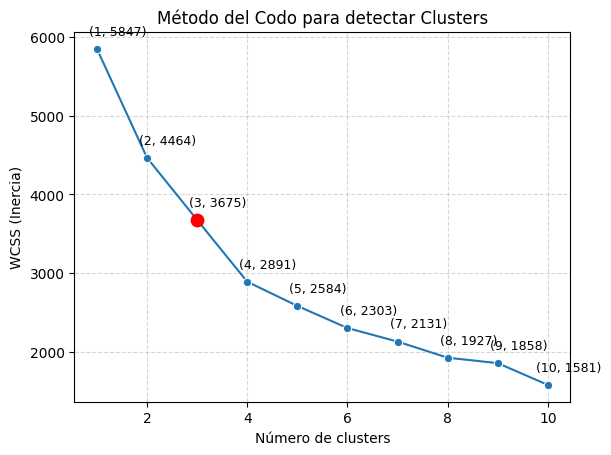

(   n_cluster         wcss        dwcss  dn_cluster        slope     d_slope
 0          1  5847.309473          NaN         NaN          NaN         NaN
 1          2  4464.967223 -1382.342249         1.0 -1382.342249         NaN
 2          3  3675.993634  -788.973590         1.0  -788.973590  593.368659
 3          4  2891.635167  -784.358467         1.0  -784.358467    4.615123
 4          5  2584.789410  -306.845757         1.0  -306.845757  477.512709
 5          6  2303.875891  -280.913519         1.0  -280.913519   25.932238
 6          7  2131.798012  -172.077879         1.0  -172.077879  108.835640
 7          8  1927.143829  -204.654183         1.0  -204.654183  -32.576304
 8          9  1858.131640   -69.012189         1.0   -69.012189  135.641994
 9         10  1581.686027  -276.445613         1.0  -276.445613 -207.433424,
 n_cluster        3.000000
 wcss          3675.993634
 dwcss         -788.973590
 dn_cluster       1.000000
 slope         -788.973590
 d_slope        5

In [26]:
# Aplicamos el método del codo

# Seleccionamos los primeros 5 componentes principales
X_unsupervised = data.iloc[:, 2:7].copy() 

elbow_method(X_unsupervised, GRAPH_BASE_PATH / "codo_metodo_nclusters.png")

In [27]:

def run_silhouette_score(
    data: pd.DataFrame,
    n_clusters: int,
    n_rows: int = 3,
    n_cols: int = 3
) -> Tuple[np.ndarray[Any, np.dtype[np.float64]], int]:
    """
    Calcula y visualiza el coeficiente de silueta para diferentes números de clusters.

    Esta función entrena un modelo KMeans para un rango de clusters (desde 2 hasta n_clusters+1),
    calcula el coeficiente de silueta por muestra y el promedio, y genera gráficos de análisis
    de silueta. Finalmente, determina el número óptimo de clusters según el máximo coeficiente
    promedio.

    Parameters
    ----------
    data : pd.DataFrame
        DataFrame con los datos ya preprocesados y listos para clustering.
        Asume que los datos están normalizados/escalados si es necesario.
    n_clusters : int
        Número máximo de clusters a evaluar. Se evaluarán desde 2 hasta n_clusters+1.
    n_rows : int, default=3
        Número de filas en la cuadrícula de subplots para los gráficos de silueta.
    n_cols : int, default=3
        Número de columnas en la cuadrícula de subplots para los gráficos de silueta.

    Returns
    -------
    Tuple[np.ndarray[Any, np.dtype[np.float64]], int]
        - silhouette_data : ndarray de forma (n_clusters, 2)
          Primera columna: número de clusters evaluado.
          Segunda columna: coeficiente de silueta promedio correspondiente.
        - n_clusters_opt : int
          Número óptimo de clusters según el máximo coeficiente de silueta promedio.

    Notes
    -----
    La función asume que la variable global `X_unsupervised` está definida en el entorno
    y contiene los datos sin etiquetar. También guarda automáticamente las gráficas en
    './graphs/training/' y las muestra en pantalla.
    """
    
    # Inicializar matriz para almacenar resultados: [n_clusters, coeficiente_silueta]
    silhouette_data: np.ndarray[Any, np.dtype[np.float64]] = np.zeros([n_clusters, 2])

    # Contadores para posicionar los subplots en la cuadrícula
    i_row: int = 0
    i_col: int = 0

    # Crear figura con subplots organizados en una cuadrícula
    fig, ax_1 = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))

    # Iterar sobre diferentes números de clusters (desde 2 hasta n_clusters+1)
    for n_clusters_opt in range(2, n_clusters + 2):
        # Configurar límite del eje X para el coeficiente de silueta (rango válido: -1 a 1, pero típicamente 0 a 1)
        ax_1[i_row, i_col].set_xlim([-0.1, 1])
        
        # --- 1. Entrenar modelo KMeans y predecir etiquetas ---
        clusterer: KMeans = KMeans(n_clusters=n_clusters_opt, random_state=10)
        cluster_labels: np.ndarray[Any, Any] = clusterer.fit_predict(data)  # Nota: Se asume que data es X_unsupervised

        # --- 2. Calcular coeficiente de silueta promedio (línea punteada roja) ---
        silhouette_avg = silhouette_score(data, cluster_labels)
        print(f"Para n_clusters = {n_clusters_opt}, el promedio es: {silhouette_avg:.3f}")

        # --- 3. Calcular coeficiente de silueta para cada muestra ---
        sample_silhouette_values = np.asarray(silhouette_samples(data, cluster_labels))

        # --- 4. Construir el gráfico de silueta por cluster ---
        y_lower = 10  # Posición inicial en Y para el primer cluster
        for i in range(n_clusters_opt):
            # Seleccionar coeficientes de las muestras que pertenecen al cluster i
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()  # Orden ascendente para mejor visualización

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            # Asignar un color diferente a cada cluster usando la paleta nipy_spectral
            color = plt.colormaps['nipy_spectral'](float(i) / n_clusters_opt)
            ax_1[i_row, i_col].fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7
            )

            # Actualizar posición para el siguiente cluster (dejar un espacio de 10 unidades)
            y_lower = y_upper + 10

        # Dibujar línea vertical que indica el coeficiente promedio global
        ax_1[i_row, i_col].axvline(x=silhouette_avg, color="red", linestyle="--")
        
        # Configurar título, etiquetas y detalles del subplot
        ax_1[i_row, i_col].set_title(f"Análisis de silueta para k = {n_clusters_opt}, cs={np.round(silhouette_avg, 4)}")
        ax_1[i_row, i_col].set_xlabel('Coeficiente silueta')
        # Nota: El eje Y no tiene etiqueta porque representa los índices de las muestras agrupadas

        # --- 5. Almacenar resultados en la matriz silhouette_data ---
        silhouette_data[n_clusters_opt - 2, 0] = n_clusters_opt
        silhouette_data[n_clusters_opt - 2, 1] = silhouette_avg

        # --- 6. Avanzar al siguiente subplot en la cuadrícula (orden por filas) ---
        if i_col < n_cols - 1:
            i_col += 1
        else:
            i_col = 0
            if i_row < n_rows - 1:
                i_row += 1
            else:
                i_row = 0  # Si se acaba la cuadrícula, vuelve a empezar (sobrescribe)

    # Ajustar diseño y guardar/mostrar la figura con todos los subplots
    plt.tight_layout()
    plt.savefig(f'./graphs/training/graf_silueta.png')
    plt.show()

    # --- 7. Gráfico de línea del coeficiente promedio vs número de clusters ---
    silhouette_df = pd.DataFrame(silhouette_data, columns=['n_cluster', 'cs'])

    sns.lineplot(data=silhouette_df, x='n_cluster', y='cs', marker='o')
    
    # Marcar un punto específico (ejemplo fijo: n_clusters=4, cs=0.4034)
    # Nota: Este punto puede no corresponder al máximo; es un ejemplo o referencia externa
    sns.scatterplot(x=[4], y=[0.4034], color='red', s=80, zorder=5)

    # Anotar cada punto con su par (n_clusters, cs redondeado)
    for x, y in zip(silhouette_df["n_cluster"], silhouette_df["cs"]):
        plt.annotate(
            f'{x, np.round(y, 4)}',
            (x, y),
            textcoords="offset points",
            xytext=(15, 10),
            ha='center',
            fontsize=9
        )

    # Personalizar el gráfico de líneas
    plt.title('Análisis de coeficiente de silueta')
    plt.xlabel('n_clusters')
    plt.ylabel('Coef. silueta promedio')
    plt.grid(linestyle='--', alpha=0.5)
    # Opciones comentadas para ajustar límites si es necesario
    # plt.ylim([0.35, 0.415])
    # plt.xlim([1, 11])
    
    plt.savefig(f'./graphs/training/coef_silueta_line.png')
    plt.show()

    # --- 8. Determinar el número óptimo de clusters ---
    # Se busca el máximo en la columna de coeficientes (columna 1)
    idx_max = np.argmax(silhouette_data[:, 1])
    n_clusters_opt = int(silhouette_data[idx_max, 0])
    print(f'El n_cluster óptimo es {n_clusters_opt}')

    return silhouette_data, n_clusters_opt

Para n_clusters = 2, el promedio es: 0.394
Para n_clusters = 3, el promedio es: 0.401
Para n_clusters = 4, el promedio es: 0.403
Para n_clusters = 5, el promedio es: 0.365
Para n_clusters = 6, el promedio es: 0.382
Para n_clusters = 7, el promedio es: 0.384
Para n_clusters = 8, el promedio es: 0.388
Para n_clusters = 9, el promedio es: 0.392
Para n_clusters = 10, el promedio es: 0.356


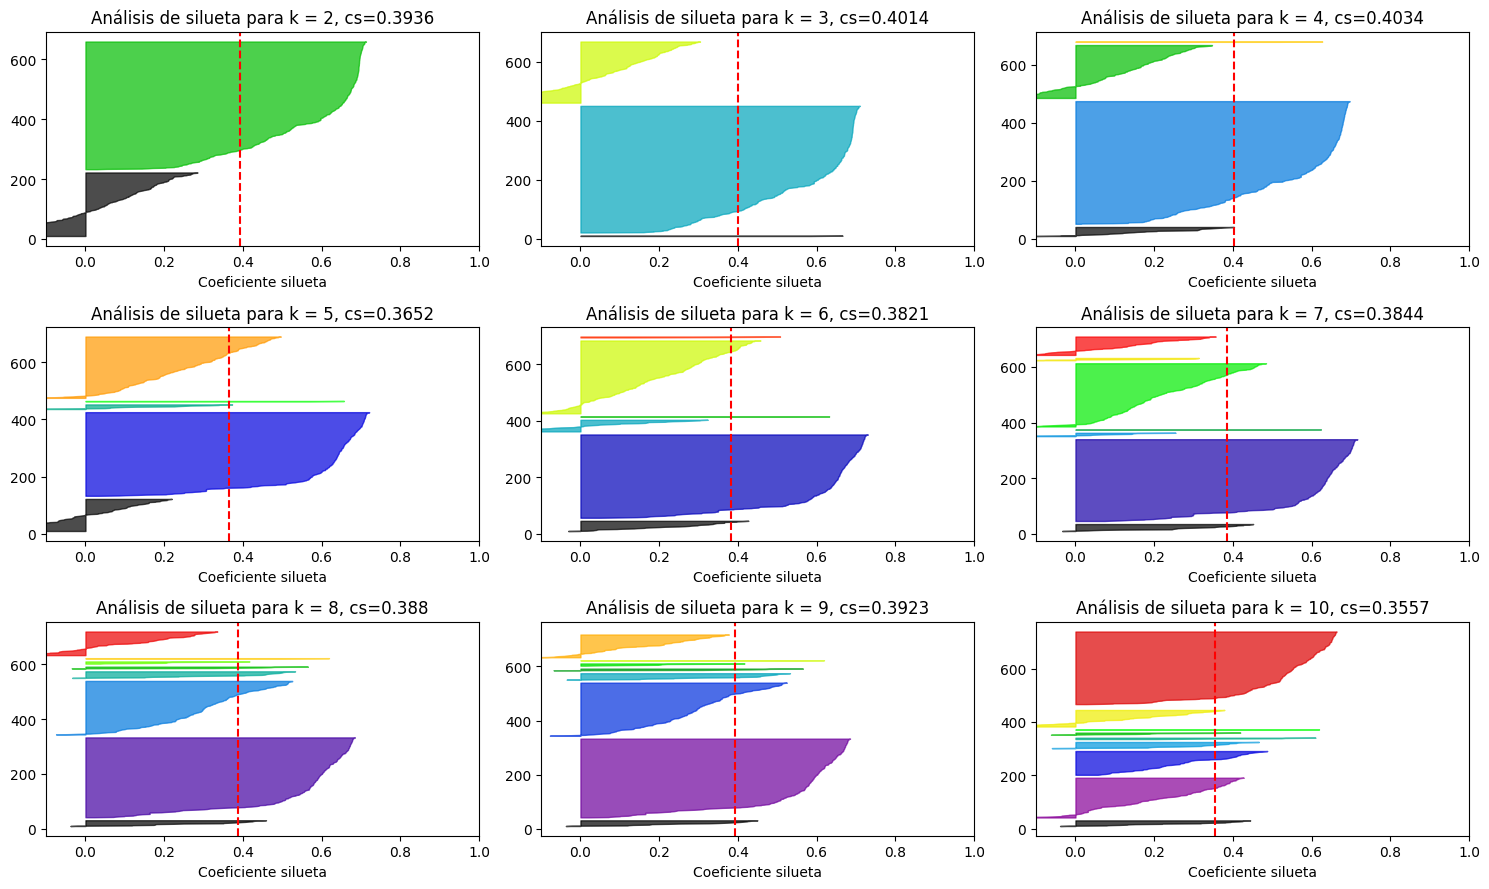

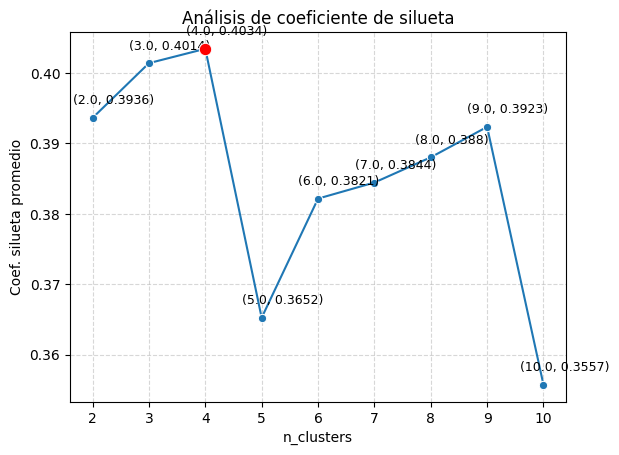

El n_cluster óptimo es 4


In [30]:
# metodo de coeficiente de silueta
n_range_clusters = 9
n_rows = 3
n_cols = 3

silhouette_data, n_clusters_opt = run_silhouette_score(X_unsupervised, n_range_clusters, n_rows, n_cols)

### Entrenamiento del Modelo de Clasificación

Una vez identificado el número de grupos (supongamos que el "codo" está en 3 o 4 clusters), ejecutamos el entrenamiento final.

In [31]:
data_pc10 = data.drop(columns=['referencia', 'fecha'], axis=0)

# Entrenamos con el número de clusters elegido
model_knn = KMeans(n_clusters=n_clusters_opt, init='k-means++', random_state=42)
clusters_knn = model_knn.fit_predict(data_pc10)
centroides_knn = model_knn.cluster_centers_


### Gráfico de Dispersión 2D (Visualización Estándar)

Primero, asegúrate de tener en un solo lugar los componentes y las etiquetas de los clusters que generó el modelo.

In [32]:
data_train = data.copy()
data_train['cluster_knn'] = clusters_knn # Las etiquetas que generó el modelo K-Means
data_train.head()

,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_knn
0,04/06/2001,P1,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,0
1,04/06/2001,P2,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,0
2,04/06/2001,P3,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,0
3,04/06/2001,P4,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,0
4,04/07/2001,P1,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,0


Este gráfico te permitirá ver cómo el algoritmo separó las muestras de agua. Si los grupos están bien definidos, verás "nubes" de puntos de distintos colores.

In [33]:

def empty_directory(directory_path):
    path = Path(directory_path)
    if path.is_dir():
        return not any(path.iterdir())
    else:
        raise ValueError("This path is not a directory")

def graph_dist_clusters(data, column_names, pca_n_cols, pca_n_rows, column_analysed, output_path):
    """
    Genera una matriz de gráficos de dispersión para comparar todas las combinaciones de columnas.
    
    Para cada columna principal, crea una cuadrícula de gráficos mostrando su relación
    con todas las demás columnas, coloreando los puntos según un cluster o categoría.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame con los datos a graficar (normalmente datos PCA)
    
    column_names : list
        Lista con los nombres de las columnas a graficar
    
    pca_n_cols : int
        Número de columnas en la cuadrícula de subplots
    
    pca_n_rows : int
        Número de filas en la cuadrícula de subplots
    
    column_analysed : str
        Nombre de la columna que se usa para colorear los puntos (ej: 'cluster', 'categoria')
    
    output_path : str
        Ruta base donde se guardarán los gráficos (se añadirá el nombre de la columna)
    
    Returns
    -------
    None
        La función guarda y muestra los gráficos
    
    Examples
    --------
    >>> # Graficar componentes PCA coloreados por cluster
    >>> graph_dist_clusters(
    ...     data=df_pca,
    ...     column_names=['PC1', 'PC2', 'PC3', 'PC4'],
    ...     pca_n_cols=2,
    ...     pca_n_rows=2,
    ...     column_analysed='cluster',
    ...     output_path='./graphs/clusters/'
    ... )
    """
    
    # 1. Verificar que el directorio esté vacío
    # Extraer el directorio padre de la ruta
    # Ejemplo: './graphs/clusters/archivo.png' -> './graphs/clusters'
    directory_path = Path(output_path).parent
    
    try:
        # Verificar si el directorio está vacío (para no sobrescribir)
        if empty_directory(directory_path):
            print("Directory is empty. ok")
            
            # 2. Crear un gráfico por cada columna principal
            # Para cada columna que usaremos como eje X
            for pca_column_name_1 in column_names:

                # Crear una cuadrícula de subplots (filas x columnas)
                fig_pca, ax_pca = plt.subplots(
                    pca_n_rows, 
                    pca_n_cols, 
                    figsize=(5 * pca_n_cols, 3 * pca_n_rows),  # Tamaño ajustable
                    squeeze=False  # Mantener estructura 2D aunque sea 1x1
                )
                
                # Contadores para posicionar los gráficos en la cuadrícula
                pca_i_row = 0  # Fila actual
                pca_i_col = 0  # Columna actual
                
                # 3.Graficar contra todas las demás columnas
                # Para cada columna que usaremos como eje Y
                for pca_column_name_2 in column_names:
                    
                    # Gráfico de dispersión
                    sns.scatterplot(
                        data=data, 
                        x=pca_column_name_1,      # Eje X: columna principal
                        y=pca_column_name_2,      # Eje Y: columna secundaria
                        hue=column_analysed,      # Color: según cluster/categoría
                        palette='viridis',        # Paleta de colores
                        s=15,                     # Tamaño de los puntos
                        alpha=1,                  # Opacidad (1 = sólido)
                        edgecolor='w',            # Borde blanco alrededor de puntos
                        ax=ax_pca[pca_i_row, pca_i_col]  # Posición en la cuadrícula
                    )

                    # Personalizar el gráfico actual
                    ax_pca[pca_i_row, pca_i_col].set_title(f'{pca_column_name_1} vs {pca_column_name_2}')
                    ax_pca[pca_i_row, pca_i_col].set_xlabel(f'{pca_column_name_1}')
                    ax_pca[pca_i_row, pca_i_col].set_ylabel(f'{pca_column_name_2}')
                    ax_pca[pca_i_row, pca_i_col].grid(True, linestyle='--', alpha=0.5)  # Cuadrícula punteada

                    # 4. Actualizar posición para el siguiente gráfico
                    # Avanzar por filas primero
                    if pca_i_row < pca_n_rows - 1:
                        pca_i_row += 1  # Siguiente fila
                    else:
                        pca_i_row = 0   # Volver a primera fila
                    
                    # Luego avanzar por columnas
                    if pca_i_col < pca_n_cols - 1:
                        pca_i_col += 1  # Siguiente columna
                    else:
                        pca_i_col = 0   # Volver a primera columna
                
                # 5. Guardar y mostrar la figura completa
                plt.tight_layout()  # Ajustar espacios para que no se superpongan
                plt.savefig(output_path + f'{pca_column_name_1}.png')  # Guardar
                plt.show()  # Mostrar en pantalla
        else:
            # El directorio tiene archivos, no se debe guardar
            print(f"This directory {directory_path} is not empty. Choose another one.")
            
    except ValueError as e:
        # Capturar error si empty_directory() falla
        print(e)
    

In [35]:
column_names_knn = data_train.drop(columns=['fecha', 'referencia', 'cluster_knn']).copy().columns.to_list()
pca_n_rows = 5
pca_n_cols = 2

out_path ='./graphs/training/res_knn_class_'

graph_dist_clusters(data, column_names_knn, pca_n_cols, pca_n_rows, 'cluster_knn', out_path)

This directory graphs/training is not empty. Choose another one.


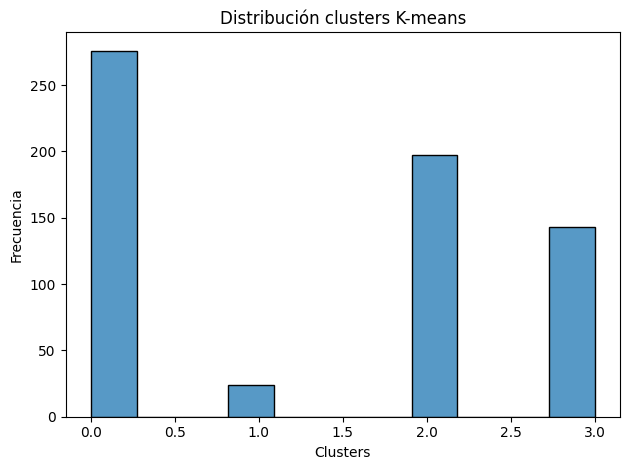

In [36]:
sns.histplot(data=data_train, x='cluster_knn')
plt.title('Distribución clusters K-means')
plt.xlabel(f'Clusters')
plt.ylabel(f'Frecuencia')

plt.tight_layout()
plt.savefig(f'./graphs/training/hist_res_knn.png')
plt.show()

### Entrenamiento con Autoencoder

In [39]:

def run_autoecoder_k(data: pd.DataFrame, input_dim: int, output_dim: int, n_cluters: int) -> Tuple[np.ndarray, Model, Model, StandardScaler] :
    # 1. Se debe escalar los datos para que las distancias en el AE sean uniformes
    scaler = StandardScaler()
    data_scaled_aec = scaler.fit_transform(data)
    print(data_scaled_aec.shape)

    # 2. Definiendo arquitectura de autoencoder
    input_layer = Input(shape=(input_dim,))
    # Encoder
    encoded = Dense(8, activation='relu')(input_layer)
    latent_space = Dense(output_dim, activation='relu')(encoded) # Capa clave
    # Decoder
    decoded = Dense(8, activation='relu')(latent_space)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    
    # Modelos
    autoencoder = Model(input_layer, output_layer)
    encoder = Model(input_layer, latent_space) # Para extraer características

    # Compilando autoencoder
    autoencoder.compile(optimizer='adam', loss='mse')

    # 3. Entrenamiento
    autoencoder.fit(data_scaled_aec, data_scaled_aec, epochs=50, batch_size=32, shuffle=True, verbose=0)

    # 4. Obtener las representaciones en el espacio latente
    latent_representation = encoder.predict(data_scaled_aec)

    # 5. Clustering (K-Means) para obtener centroides
    # Supongamos que buscas 3 clusters de perfiles químicos
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(latent_representation)

    # 6. Obtener los centroides
    centroides_lat = kmeans.cluster_centers_

    print(f"Forma de los centroides (Clusters, Dimensión Latente): {centroides_lat.shape}")
    print("Centroides en el espacio latente:\n", centroides_lat)

    return centroides_lat, autoencoder, encoder, scaler

In [40]:
centroides_aek, autoencoder, encoder, scaler_aek = run_autoecoder_k(data_pc10, input_dim= 10, output_dim= 5, n_cluters= 4)

(640, 10)
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Forma de los centroides (Clusters, Dimensión Latente): (4, 5)
Centroides en el espacio latente:
 [[5.2575164  0.25953853 3.6737835  3.5614364  0.995145  ]
 [2.5526667  0.64538276 1.2966697  0.7227715  1.6124527 ]
 [2.7990918  1.7814958  5.4628167  1.8078052  2.8224583 ]
 [0.5114441  8.445777   1.241953   1.8664469  0.68505234]]


In [43]:
# 7. Definir el Decoder como un modelo independiente
# Tomamos las capas del autoencoder que van después del espacio latente
# (Ajusta los índices de las capas según cómo definiste tu modelo)
input_decoder = Input(shape=(5,))
decoder_layer1 = autoencoder.layers[-2](input_decoder) # La capa de 8 neuronas
output_decoder = autoencoder.layers[-1](decoder_layer1) # La capa final de 10
decoder_model = Model(input_decoder, output_decoder)

# 8. "Pasar" los centroides por el Decoder
centroides_pca = decoder_model.predict(centroides_aek)

# 9. (Opcional) Revertir el escalado
# Si usaste StandardScaler al inicio, debes devolver los datos a su escala PCA original
centroides_aek_pq = scaler_aek.inverse_transform(centroides_pca)

print("Forma de los centroides en espacio PCA:", centroides_aek_pq.shape)
print("Valores de los centroides (10 dimensiones):\n", centroides_aek_pq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Forma de los centroides en espacio PCA: (4, 10)
Valores de los centroides (10 dimensiones):
 [[3.2329060e-02 1.0230734e-03 2.5182508e-02 3.5029724e-03 3.5968339e-03
  7.8513922e-06 7.3308814e-03 2.1830019e-05 5.2106534e-03 2.0592624e-01]
 [3.5384709e-01 3.6440570e-02 4.5796004e-01 7.5848572e-02 5.3654864e-02
  8.4174694e-03 2.1030207e-01 1.2839529e-02 5.6029730e-02 2.3511995e-01]
 [2.6179731e-01 1.4129336e-02 9.3026012e-02 2.0914346e-03 3.0952054e-01
  4.3401320e-04 1.1121528e-01 6.7221466e-04 6.2069988e-01 9.3949883e-04]
 [1.4403719e+00 1.8014605e-03 1.3139060e-01 1.0723398e+00 1.8199439e-03
  9.8364800e-01 2.4518598e-02 8.5888875e-01 4.9453277e-02 1.9019497e-04]]


### Entrenamiento modelo SOM (Kohonen)

In [45]:

from typing import List


def run_som_k(data: pd.DataFrame, grid_dim: np.ndarray, n_iterations: int = 1000) -> Tuple[MiniSom, np.ndarray, np.ndarray]:
    # 1. Simulación/Carga de tus 10 componentes PCA (640 filas)
    # data = tu_dataframe_pca.values 
    # data = np.random.rand(640, 10) 

    # El SOM es sensible a la escala. Escalamos de 0 a 1.
    scaler = MinMaxScaler()
    data_scaled_som = scaler.fit_transform(data)

    # 2. Configuración del SOM
    # Para 640 muestras, una rejilla de 10x10 neuronas suele ser adecuada
    som_grid_rows = grid_dim[0]
    som_grid_cols = grid_dim[1]
    input_len = data_scaled_som.shape[1] # Tus 10 componentes PCA

    som = MiniSom(som_grid_rows, som_grid_cols, input_len, 
                sigma=1, learning_rate=0.5, random_seed=42)
    # Inicialización de pesos y entrenamiento
    som.pca_weights_init(data_scaled_som)
    som.train_random(data_scaled_som, num_iteration=n_iterations, verbose=True)

    # 3. Visualización del "U-Matrix" (Mapa de Distancias)
    # Los colores oscuros son grupos de datos, los claros son "fronteras"
    plt.figure(figsize=(8, 8))
    plt.pcolor(som.distance_map().T, cmap='bone_r') # Distancia entre neuronas
    plt.colorbar()

    # 4. Obtener a qué "neurona" (cluster) pertenece cada muestra
    # Cada fila de tu base de datos se asigna a una coordenada (x, y)
    clusters = np.array([som.winner(x) for x in data_scaled_som])

    # Ejemplo: Ver la coordenada de la primera muestra de agua
    print(f"La primera muestra pertenece a la neurona: {clusters[0]}")

    # 5. Obtener los "Centroides"
    # En un SOM, los pesos de cada neurona actúan como el centroide de ese grupo
    pesos = som.get_weights() 
    # pesos[x, y] te daría el perfil químico promedio de ese punto del mapa

    return som, data_scaled_som, pesos



 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.05350235155302711
La primera muestra pertenece a la neurona: [19 27]


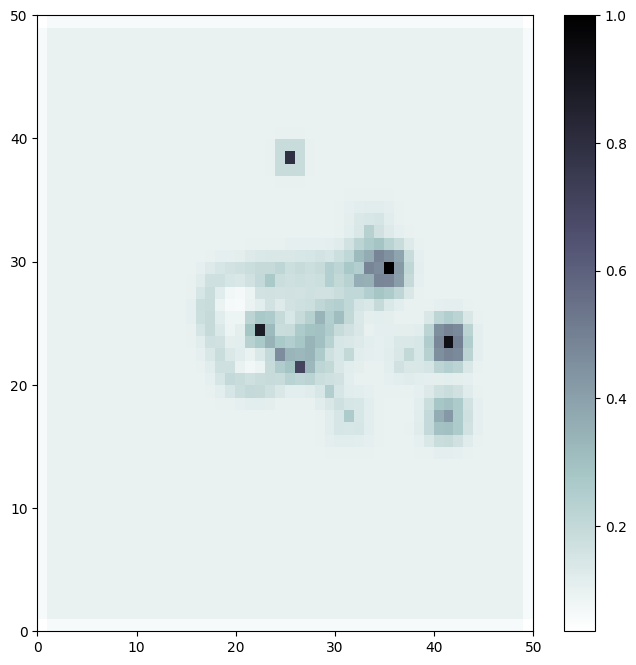

In [49]:
grid_dim =np.array([50, 50])

model_som, data_scaled_som, pesos_som = run_som_k(data_pc10, grid_dim)

In [50]:
# Obtenemos las coordenadas de la neurona ganadora para cada una de las 640 filas
ganadoras = [model_som.winner(x) for x in data_scaled_som]

# Contamos cuántas neuronas únicas fueron seleccionadas
centroides_activos = len(set(ganadoras))

print(f"El SOM tiene un total de {grid_dim[0] * grid_dim[0]} neuronas (posibles centroides).")
print(f"De ellas, {centroides_activos} centroides capturaron al menos una muestra de agua.")


El SOM tiene un total de 2500 neuronas (posibles centroides).
De ellas, 116 centroides capturaron al menos una muestra de agua.


In [51]:
# 1. Aplanamos los pesos de la rejilla (de 10x10x10 a 100x10)
pesos_aplanados = pesos_som.reshape(-1, 10)

# 2. Agrupamos las neuronas en, por ejemplo, 3 clusters químicos
n_clusters = 4
km = KMeans(n_clusters=n_clusters, random_state=42)
km.fit(pesos_aplanados)

# 3. Estos son tus centroides finales en la dimensión del PCA (10)
centroides_som = km.cluster_centers_

print("Centroides finales (3 grupos, 10 variables PCA):")
print(centroides_som)

Centroides finales (3 grupos, 10 variables PCA):
[[-0.30627161  0.14812262  0.47509384  0.56888627  0.43533559  0.11212191
   0.60162698  0.09218235  0.30016078  0.48557237]
 [ 0.6640145   0.15034103  0.47723324  0.56858294  0.43581592  0.11210063
   0.5995143   1.06067346  0.29826701  0.48616412]
 [-0.36398188  0.1469775   0.47662284  0.56874203  0.4353371   0.11195346
   0.60137763  1.10765118  0.30096983  0.48513363]
 [ 0.70183756  0.14686703  0.47492303  0.57082165  0.43417578  0.11213054
   0.60143162  0.04018909  0.30327812  0.48292274]]


### Híbrido ABC + K-Means (Refinamiento)
En este modelo, el ABC se encarga de la exploración global y el K-Means de la explotación local.

1. Fase Global (ABC): Las abejas exploran el espacio de datos para encontrar regiones prometedoras donde podrían estar los clusters.

2. Fase Local (K-Means): Una vez que el ABC encuentra una solución cercana a la óptima, se utiliza el operador de K-Means para "pulir" esos centroides y ajustarlos rápidamente a los datos circundantes.

Resultado: Es mucho más rápido que el ABC puro y más preciso que el K-Means solo.


### El Flujo de Trabajo

La idea central es usar el ABC para inicializar de forma inteligente los centroides y luego dejar que K-Means termine el trabajo sucio de convergencia.

1. Inicialización (Abejas Exploradoras)En lugar de elegir puntos al azar, generas una población de "abejas". Cada abeja lleva consigo un vector que representa los centros de los $k$ clusters.

- Población: $N$ soluciones potenciales.
- Posición: Coordenadas de los centros de los grupos en el espacio de datos.2. Ciclo de 

2. Optimización Global (Fase ABC)Durante un número determinado de iteraciones, las abejas realizan tres tareas:
- Abejas Empleadas: Buscan nuevas soluciones cerca de las actuales (modifican un poco los centros) para ver si el error (SSE) disminuye.
- Abejas Observadoras: Eligen las mejores soluciones encontradas basándose en una probabilidad de "fitness". Entre mejor sea el clustering, más abejas irán a esa zona.
- Abejas Exploradoras: Si una solución no mejora después de varios intentos, la abeja la abandona y vuela a una zona totalmente nueva del dataset para evitar el estancamiento.

3. El "Salto" a K-Means (Refinamiento Local)Una vez que el algoritmo ABC ha convergido en una región prometedora (es decir, ya tenemos centros muy cercanos a los reales), tomamos la mejor abeja y usamos sus posiciones como el init de un algoritmo K-Means tradicional.

4. FinalizaciónK-Means realiza sus iteraciones finales (que suelen ser muy pocas en este punto) para asegurar que cada punto esté asignado al centroide más cercano de forma exacta.

```bash
# 1. Fase Global (Exploración con ABC)
for iteracion in rango(max_iter_abc):
    for abeja in poblacion:
        nueva_posicion = mover_abeja(abeja)
        evaluar_fitness(nueva_posicion) # Usando Suma de Errores Cuadráticos
    manejar_abejas_exploradoras() # Evita mínimos locales

# 2. Selección del Ganador
mejor_solucion = obtener_mejor_abeja(poblacion)

# 3. Fase Local (Refinamiento con K-Means)
# Usamos la mejor posición del ABC como semilla
kmeans_final = KMeans(n_clusters=k, init=mejor_solucion.centros)
kmeans_final.fit(datos)
```

### Funcion de aptitud para algoritmo ABC

In [52]:

def fitness_aptitude(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    # Penalización si se pierde un cluster
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    # Cálculo de SSE (Suma de errores cuadráticos)
    sse = 0
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    return sse

# 1.2. Índice de Davies-Bouldin (DBI)
def fitness_db_index(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    # El objetivo es MINIMIZAR este índice
    return davies_bouldin_score(data, labels)

# 1.3 Índice de Calinski-Harabasz (Varianza entre/dentro)
def fitness_calinski(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    score = calinski_harabasz_score(data, labels)
    # Como buscamos MINIMIZAR en tu config, retornamos el negativo
    return -score

# 1.4 Función de Fitness Combinada (Híbrida)
def fitness_hybrid(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    # 1. Calcular SSE
    sse = 0
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    
    # 2. Calcular separación entre centroides (queremos que sea grande)
    # Calculamos la distancia promedio entre todos los pares de centros
    sep_distances = cdist(centroids, centroids, 'euclidean')
    # Sumamos solo la parte triangular superior para no repetir distancias ni usar la diagonal (0)
    separation = np.sum(np.triu(sep_distances, k=1))
    
    # Retornamos SSE penalizado por poca separación
    # (A menor separación, mayor el valor del fitness)
    return sse / (separation + 1e-6)


class MultiFitnessProblem(Problem):

    def __init__(self, lb, ub, minmax, data, n_clusters, n_features, fitness_logic, **kwargs):
        self.data = data
        self.n_clusters = n_clusters
        self.fitness_logic = fitness_logic
        self.n_features = n_features

        super().__init__(FloatVar(lb=lb, ub=ub), minmax)

    def obj_func(self, x):
        return self.fitness_logic(x, self.data, self.n_clusters, self.n_features)

In [ ]:
def run_abck(data: pd.DataFrame, 
             fitness_function: Callable, 
             n_clusters_opt: int = 4) -> Tuple[pd.DataFrame, ABC.OriginalABC, KMeans]:
    """
    Ejecuta un algoritmo híbrido ABC + K-Means para clustering.

    Parámetros:
    -----------
    data : pd.DataFrame
        Datos de entrada (características a clusterizar)
    fitness_function : Callable
        Función de fitness para evaluar la calidad de los centroides
    n_clusters_opt : int, default=4
        Número de clusters a formar

    Retorna:
    --------
    Tuple[pd.DataFrame, ABC.OriginalABC, KMeans]
        - DataFrame con los datos originales + columna de clusters
        - Modelo ABC entrenado
        - Modelo K-Means entrenado
    """

    # Mostramos información básica de los datos
    print(data)

    # ===== 1. Configuración del Problema =====
    # Obtenemos el número de características (columnas) de los datos
    n_features = data.shape[1]
    
    # Creamos los límites inferior y superior para los centroides
    # Cada centroide es un punto con n_features coordenadas
    # Multiplicamos por n_clusters_opt porque tenemos varios centroides
    low_bounds = np.min(data, axis=0).tolist() * n_clusters_opt
    up_bounds = np.max(data, axis=0).tolist() * n_clusters_opt

    # Configuramos el problema de optimización multiobjetivo
    abc_problem = MultiFitnessProblem(
        ub=up_bounds,
        lb=low_bounds,
        data=data,
        minmax="min",  # Minimizamos la función fitness (SSE)
        n_clusters=n_clusters_opt,
        n_features=n_features,
        fitness_logic=fitness_function
    )

    # ===== 2. Ejecución de ABC (Artificial Bee Colony) =====
    # Creamos el modelo ABC con 100 épocas y 50 abejas
    model_abck = ABC.OriginalABC(epoch=100, pop_size=50)

    # Ejecutamos el algoritmo para resolver el problema
    g_best = model_abck.solve(abc_problem, seed=45)

    # Guardamos el historial de mejores soluciones (para análisis)
    if model_abck.history is not None:
        # Lista de posiciones de la mejor solución en cada época
        history_pos = np.array([agent.solution for agent in model_abck.history.list_global_best])
    else:
        history_pos = np.array([])  # Si no hay historial, array vacío

    # Extraemos la mejor solución encontrada y su fitness
    best_pos = g_best.solution   # Posición (centroides óptimos)
    best_fit = g_best.target.fitness  # Valor de fitness (SSE)

    print(f"Mejor Fitness (SSE) encontrado por ABC: {best_fit}")

    # ===== 3. FASE HÍBRIDA: Refinamiento Local con K-Means =====
    # Usamos los centroides encontrados por ABC como punto de partida
    # Reorganizamos el vector de centroides en una matriz de forma (clusters, características)
    init_centroids = best_pos.reshape((n_clusters_opt, n_features))

    # Creamos y entrenamos K-Means usando los centroides iniciales de ABC
    model_kmeans = KMeans(n_clusters=n_clusters_opt, 
                          init=init_centroids, 
                          n_init=1,  # Solo 1 inicialización (usamos la de ABC)
                          max_iter=500)  # Iteraciones para refinar
    
    # Ajustamos el modelo a los datos
    model_kmeans.fit(data)
    
    # Agregamos la columna con los clusters al DataFrame original
    data['cluster_abck'] = model_kmeans.predict(data)

    print(f"Refinamiento K-Means completado. SSE Final: {model_kmeans.inertia_}")

    # Mostramos una vista previa de los resultados
    display(data.head())

    # Retornamos los resultados
    return data, model_abck, model_kmeans

In [54]:
n_clusters_opt = 4
X_data = data_train.drop(columns=['fecha', 'referencia', 'cluster_knn']).copy()
n_features = X_data.shape[1]

data_abck, model_abck, model_k = run_abck(X_data, fitness_calinski, n_clusters_opt)

if model_abck.history is not None:
    path_nd = np.array([agent.solution for agent in model_abck.history.list_global_best])

2026/04/29 07:06:24 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(epoch=100, pop_size=50, n_limits=25)
2026/04/29 07:06:24 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -81.80364240751487, Global best: -81.80364240751487, Runtime: 0.07676 seconds
2026/04/29 07:06:24 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -81.80364240751487, Global best: -81.80364240751487, Runtime: 0.07261 seconds


          PC1       PC2       PC3       PC4        PC5        PC6       PC7  \
0   -2.173814  0.560687 -0.244653 -0.000022  -0.198642  -0.297102 -0.449977   
1   -2.135326  0.504553 -0.095536 -0.305302  -0.183530   0.056558 -0.207734   
2   -2.165984  0.458176 -0.002323 -0.326949  -0.166642   0.099856 -0.208867   
3   -2.211613  0.503966 -0.129927 -0.042172  -0.189566  -0.223255 -0.443616   
4   -2.324292  0.460397 -0.136303  0.202740  -0.166470  -0.296635 -0.488494   
..        ...       ...       ...       ...        ...        ...       ...   
635  1.285226 -0.218830 -0.664423 -0.236297   0.242890  -0.547417 -0.125620   
636  2.127979 -0.625815  1.358942  0.097421  -0.151548  -0.054191  0.606738   
637  0.143153  0.575170  0.865284 -0.296932   0.223312  -0.294826  0.112989   
638 -0.412851 -0.637269 -0.122417 -1.027177  -4.857845   4.332729 -2.052943   
639  1.049074  0.315701 -1.626347 -8.617998 -12.905628  13.121317 -4.097254   

          PC8       PC9      PC10  
0   -0.315806 -

2026/04/29 07:06:24 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.08058 seconds
2026/04/29 07:06:24 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.07045 seconds
2026/04/29 07:06:25 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.07246 seconds
2026/04/29 07:06:25 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 6, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.07180 seconds
2026/04/29 07:06:25 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 7, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.06728 seconds
2026/04/29 07:06:25 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoc

Mejor Fitness (SSE) encontrado por ABC: -101.39681060516769
Refinamiento K-Means completado. SSE Final: 5555.456219957258


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_abck
0,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,3
1,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,3
2,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,3
3,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,3
4,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,3


In [ ]:
print(type(path_nd))
matriz_reshaped = path_nd.reshape((100, n_clusters_opt, n_features))
print(matriz_reshaped.shape)
# print(matriz_reshaped)

<class 'numpy.ndarray'>
(100, 4, 10)


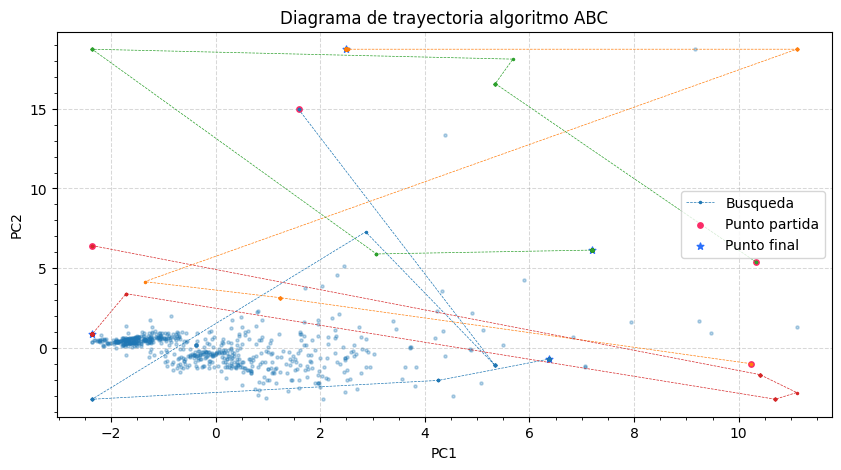

In [ ]:
# indices de columas de PC
col_i_x = 0
col_i_y = 1

fig_003, ax_003 = plt.subplots(figsize=(10,5))

for c_i in range(n_clusters_opt):
    ax_003.plot(matriz_reshaped[:,c_i,:][:,col_i_x], matriz_reshaped[:,c_i,:][:,col_i_y], '.--', linewidth=0.5, markersize=3)
    ax_003.scatter(matriz_reshaped[:,c_i,:][0,col_i_x], matriz_reshaped[:,c_i,:][0,col_i_y], marker='o', s=15, color="#fb2b67")
    ax_003.scatter(matriz_reshaped[:,c_i,:][-1,col_i_x],matriz_reshaped[:,c_i,:][-1,col_i_y], marker='*', s=25, color="#2b6ffb")

ax_003.scatter(data["PC1"], data["PC2"], s=5, alpha=0.30)
    
ax_003.grid(color="gray", alpha=0.30, linewidth=0.75, linestyle='dashed')
ax_003.set_xlabel("PC1")
ax_003.set_ylabel("PC2")
ax_003.minorticks_on()
ax_003.legend([f"Busqueda", "Punto partida", "Punto final"])
ax_003.set_title("Diagrama de trayectoria algoritmo ABC")
plt.show()

In [ ]:
out_path ='./graphs/training/res_abck_class_'

graph_dist_clusters(data_abck, column_names_knn, pca_n_cols, pca_n_rows, 'cluster_abck', out_path)

This directory graphs/training is not empty. Choose another one.


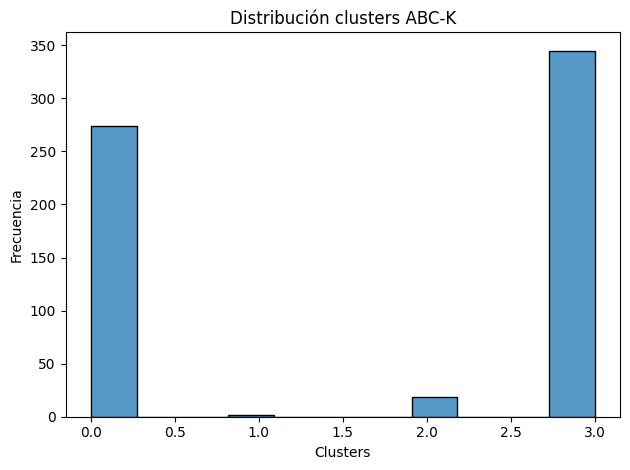

In [ ]:
sns.histplot(data=data_abck, x='cluster_abck')
plt.title('Distribución clusters ABC-K')
plt.xlabel(f'Clusters')
plt.ylabel(f'Frecuencia')

plt.tight_layout()
plt.savefig(f'./graphs/training/hist_res_abck.png')
plt.show()

In [ ]:
display(data_abck.head())
data_abck.to_csv("../data/results/pca_data_abck.csv", index=False, sep=',', encoding='utf-8')

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_abck
0,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,3
1,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,3
2,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,3
3,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,3
4,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,3


### Convirtiendo modelo a binario

In [ ]:
centroides_abck = model_k.cluster_centers_
joblib.dump(centroides_abck, '../binary/cluster_centers.joblib')

['../binary/cluster_centers.joblib']

### Comparación entre métodos

In [ ]:
print(centroides_knn.shape)
print(centroides_abck.shape)
print(centroides_aek_pq.shape)
print(centroides_som.shape)


(4, 10)
(4, 10)
(4, 10)
(4, 10)


In [ ]:
# 1. Diccionario con tus centroides (Carga aquí tus resultados de 10 dimensiones)
# Cada valor debe ser un array de (n_clusters, 10)
mis_centroides = {
    "K-Means": centroides_knn,
    "ABC + K-Means": centroides_abck,
    "Autoencoder + K-Means": centroides_aek_pq,
    "SOM + K-Means": centroides_som
}

def calcular_metricas_desde_centroides(X, centroides_dict):
    resumen = []
    
    for nombre, centros in centroides_dict.items():
        # ASIGNACIÓN: Cada punto al centroide más cercano (Distancia Euclidiana)
        distancias = cdist(X, centros, metric='euclidean')
        etiquetas = np.argmin(distancias, axis=1)
        
        # CÁLCULO DE MÉTRICAS
        # Silueta: Evalúa cohesión vs separación
        sil = silhouette_score(X, etiquetas)
        
        # Calinski-Harabasz: Mayor valor = mejor definición
        ch = calinski_harabasz_score(X, etiquetas)
        
        # Davies-Bouldin: Menor valor = clusters menos solapados
        db = davies_bouldin_score(X, etiquetas)
        
        resumen.append({
            'Método': nombre,
            'Silhouette (↑)': round(sil, 4),
            'Calinski-H (↑)': round(ch, 2),
            'Davies-Bouldin (↓)': round(db, 4)
        })
        
    return pd.DataFrame(resumen)

# 3. Ejecución
df_comparativo = calcular_metricas_desde_centroides(data_pc10, mis_centroides)

# 4. Mostrar y ordenar por el mejor Silhouette
print(df_comparativo.sort_values(by='Silhouette (↑)', ascending=False))

                  Método  Silhouette (↑)  Calinski-H (↑)  Davies-Bouldin (↓)
1          ABC + K-Means          0.2969          114.60              1.2052
2  Autoencoder + K-Means          0.2521           75.06              2.0779
0                K-Means          0.2281           91.63              1.8924
3          SOM + K-Means          0.0453           55.79              2.7677
